# Statistical analysis — main-study results

Implements the analysis plan in [docs/EXPERIMENT_PROTOCOL.md](../docs/EXPERIMENT_PROTOCOL.md) §7.

Reads `data/reports/<run_label>.csv` (long-format from `scripts/run_full_experiment.py` plus the appended `human_control` rows) and produces:

1. Per-metric Shapiro-Wilk + Levene checks
2. One-way ANOVA (or Kruskal-Wallis) across the 5 conditions, Bonferroni-corrected
3. Tukey HSD post-hoc on significant omnibus tests
4. Bootstrap 95% CIs per condition
5. Two-way ANOVA (condition × spec) for the interaction term
6. Forest plot per metric + violin plot per (condition × metric)

Runs unchanged on the real CSV once N≥5 per condition.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import scikit_posthocs as sp           # Dunn's post-hoc (pre-registered for Kruskal-Wallis)
import statsmodels.formula.api as smf
import statsmodels.api as sm

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', lambda v: f'{v:.4f}')

RUN_LABEL = 'main_001'                  # headline CSV: data/reports/main_001.csv
CSV = Path('..') / 'data' / 'reports' / f'{RUN_LABEL}.csv'
ALPHA_PER_METRIC = 0.01        # Bonferroni: 0.05 / 5 metrics
BOOTSTRAP_RESAMPLES = 10_000

df = pd.read_csv(CSV) if CSV.exists() else pd.DataFrame()
print(f'Loaded {len(df)} rows from {CSV}')
print('conditions:', sorted(df.condition.unique()) if len(df) else '(none)')
df.head()

Loaded 600 rows from ../data/reports/main_001.csv
conditions: ['antigravity', 'claude_code', 'cursor_agent', 'replit_agent']


,run_label,run_id,condition,spec_name,spec_version,rep,metric,value,unit,duration_s,timestamp
0,main_001,main_001__agent_education_system__claude_code_...,claude_code,agent_education_system,1.0.0,0,hallucinations,0.0000,count,61.6570,2026-06-01T09:32:42.626072+00:00
1,main_001,main_001__agent_education_system__claude_code_...,claude_code,agent_education_system,1.0.0,0,correction_freq,0.0000,per_kkey,61.6570,2026-06-01T09:32:42.626072+00:00
2,main_001,main_001__agent_education_system__claude_code_...,claude_code,agent_education_system,1.0.0,0,complexity_mean,2.5000,cc,61.6570,2026-06-01T09:32:42.626072+00:00
3,main_001,main_001__agent_education_system__claude_code_...,claude_code,agent_education_system,1.0.0,0,duplication_pct,0.0000,%,61.6570,2026-06-01T09:32:42.626072+00:00
4,main_001,main_001__agent_education_system__claude_code_...,claude_code,agent_education_system,1.0.0,0,security_density,95.2381,per_kloc,61.6570,2026-06-01T09:32:42.626072+00:00


In [2]:
# Quick sanity: do we have enough data?
if df.empty:
    raise SystemExit('No data yet. Run scripts/run_full_experiment.py first.')
counts = df.groupby(['condition','metric','spec_name']).size().unstack(fill_value=0)
print('Reps per (condition, metric, spec):')
counts

Reps per (condition, metric, spec):


spec_name                      agent_education_system  data_pipeline  \
condition    metric                                                    
antigravity  complexity_mean                       10             10   
             correction_freq                       10             10   
             duplication_pct                       10             10   
             hallucinations                        10             10   
             security_density                      10             10   
claude_code  complexity_mean                       10             10   
             correction_freq                       10             10   
             duplication_pct                       10             10   
             hallucinations                        10             10   
             security_density                      10             10   
cursor_agent complexity_mean                       10             10   
             correction_freq                       10             10   
             duplication_pct                       10             10   
             hallucinations                        10             10   
             security_density                      10             10   
replit_agent complexity_mean                       10             10   
             correction_freq                       10             10   
             duplication_pct                       10             10   
             hallucinations                        10             10   
             security_density                      10             10   

spec_name                      internal_tool_cli  
condition    metric                               
antigravity  complexity_mean                  10  
             correction_freq                  10  
             duplication_pct                  10  
             hallucinations                   10  
             security_density                 10  
claude_code  complexity_mean                  10  
             correction_freq                  10  
             duplication_pct                  10  
             hallucinations                   10  
             security_density                 10  
cursor_agent complexity_mean                  10  
             correction_freq                  10  
             duplication_pct                  10  
             hallucinations                   10  
             security_density                 10  
replit_agent complexity_mean                  10  
             correction_freq                  10  
             duplication_pct                  10  
             hallucinations                   10  
             security_density                 10

In [3]:
def bootstrap_ci(values, n=BOOTSTRAP_RESAMPLES, ci=0.95):
    values = np.asarray(values, dtype=float)
    if len(values) < 2:
        return float(values.mean()) if len(values) else np.nan, np.nan, np.nan
    means = [np.random.choice(values, size=len(values), replace=True).mean() for _ in range(n)]
    lo, hi = np.quantile(means, [(1-ci)/2, 1-(1-ci)/2])
    return float(values.mean()), float(lo), float(hi)

summaries = []
for (metric, condition), sub in df.groupby(['metric','condition']):
    mean, lo, hi = bootstrap_ci(sub['value'])
    summaries.append({'metric':metric,'condition':condition,'n':len(sub),
                      'mean':mean,'ci_lo':lo,'ci_hi':hi})
summary = pd.DataFrame(summaries)
summary.pivot(index='condition', columns='metric', values='mean').round(3)

metric,complexity_mean,correction_freq,duplication_pct,hallucinations,security_density
condition,,,,,
antigravity,2.6010,0.0000,4.2580,0.3330,1.4750
claude_code,3.3540,0.0000,0.0000,0.0000,42.0470
cursor_agent,2.7230,0.0000,0.9040,0.1670,43.6700
replit_agent,2.3880,0.0000,9.5560,1.0000,0.0000


## Per-metric omnibus tests (Protocol §7.1)

In [4]:
def _is_normal(g):
    # zero-range (deterministic-replay cells, Deviation 001) cannot be normal
    if np.ptp(g) == 0:
        return False
    try:
        return stats.shapiro(g).pvalue > 0.05
    except Exception:
        return False

results = []
for metric in sorted(df['metric'].unique()):
    sub = df[df['metric'] == metric]
    groups = [g['value'].values for _, g in sub.groupby('condition')]
    if len(groups) < 2 or any(len(g) < 3 for g in groups):
        print(f'{metric:25s}: skipped (need >=3 obs per group)')
        continue
    normal = all(_is_normal(g) for g in groups)
    try:
        equal_var = stats.levene(*groups).pvalue > 0.05
    except Exception:
        equal_var = False
    # correction_freq is all-zero for the AI conditions -> omnibus undefined
    if all(np.ptp(g) == 0 for g in groups):
        print(f'{metric:25s}: n/a (no variance in any condition)')
        results.append({'metric':metric,'test':'n/a','stat':np.nan,'p':np.nan,'eta_sq':0.0,'significant':False})
        continue
    if normal and equal_var:
        test = 'ANOVA'; stat, p = stats.f_oneway(*groups)
    else:
        test = 'Kruskal-Wallis'; stat, p = stats.kruskal(*groups)
    sig = p < ALPHA_PER_METRIC
    grand_mean = sub['value'].mean()
    ss_between = sum(len(g)*(g.mean()-grand_mean)**2 for g in groups)
    ss_total = ((sub['value']-grand_mean)**2).sum()
    eta2 = ss_between/ss_total if ss_total else 0.0
    results.append({'metric':metric,'test':test,'stat':round(stat,3),
                    'p':round(p,5),'eta_sq':round(eta2,3),'significant':sig})
    print(f'{metric:25s} {test:14s} stat={stat:8.3f} p={p:.5f} η²={eta2:.3f} sig={sig}')
results_df = pd.DataFrame(results)
results_df

complexity_mean           Kruskal-Wallis stat=  12.030 p=0.00728 η²=0.097 sig=True
correction_freq          : n/a (no variance in any condition)
duplication_pct           Kruskal-Wallis stat=  62.410 p=0.00000 η²=0.497 sig=True
hallucinations            Kruskal-Wallis stat=  15.761 p=0.00127 η²=0.192 sig=True
security_density          Kruskal-Wallis stat=  39.354 p=0.00000 η²=0.346 sig=True


,metric,test,stat,p,eta_sq,significant
0,complexity_mean,Kruskal-Wallis,12.0300,0.0073,0.0970,True
1,correction_freq,n/a,NaN,NaN,0.0000,False
2,duplication_pct,Kruskal-Wallis,62.4100,0.0000,0.4970,True
3,hallucinations,Kruskal-Wallis,15.7610,0.0013,0.1920,True
4,security_density,Kruskal-Wallis,39.3540,0.0000,0.3460,True


In [5]:
# Dunn's post-hoc (Bonferroni) on significant metrics.
# Pre-registered post-hoc for Kruskal-Wallis omnibus (Protocol §7.1) — not Tukey.
for _, row in results_df[results_df.get('significant', False) == True].iterrows():
    sub = df[df['metric'] == row['metric']]
    print(f"\n=== Dunn's test (Bonferroni): {row['metric']} ===")
    d = sp.posthoc_dunn(sub, val_col='value', group_col='condition', p_adjust='bonferroni')
    print(d.round(4))
    conds = d.columns.tolist()
    sig_pairs = [f'{conds[i]} vs {conds[j]} (p={d.iloc[i,j]:.4f})'
                 for i in range(len(conds)) for j in range(i+1, len(conds))
                 if d.iloc[i, j] < ALPHA_PER_METRIC]
    print('significant @ α=0.01:', sig_pairs or 'none survive Bonferroni')


=== Dunn's test (Bonferroni): complexity_mean ===
              antigravity  claude_code  cursor_agent  replit_agent
antigravity        1.0000       0.0103        1.0000        0.2901
claude_code        0.0103       1.0000        0.0590        1.0000
cursor_agent       1.0000       0.0590        1.0000        0.9317
replit_agent       0.2901       1.0000        0.9317        1.0000
significant @ α=0.01: none survive Bonferroni

=== Dunn's test (Bonferroni): duplication_pct ===
              antigravity  claude_code  cursor_agent  replit_agent
antigravity        1.0000       0.0000        0.0000        1.0000
claude_code        0.0000       1.0000        0.8310        0.0000
cursor_agent       0.0000       0.8310        1.0000        0.0000
replit_agent       1.0000       0.0000        0.0000        1.0000
significant @ α=0.01: ['antigravity vs claude_code (p=0.0000)', 'antigravity vs cursor_agent (p=0.0000)', 'claude_code vs replit_agent (p=0.0000)', 'cursor_agent vs replit_agent (p=0

## Condition × spec interaction (Protocol §7.2)

In [6]:
for metric in sorted(df['metric'].unique()):
    sub = df[df['metric'] == metric].copy()
    if sub['spec_name'].nunique() < 2 or len(sub) < 10:
        continue
    model = smf.ols('value ~ C(condition) + C(spec_name) + C(condition):C(spec_name)', data=sub).fit()
    print(f'\n=== Two-way ANOVA: {metric} ===')
    print(sm.stats.anova_lm(model, typ=2).round(4))


=== Two-way ANOVA: complexity_mean ===
                           sum_sq       df        F  PR(>F)
C(condition)              15.5576   3.0000  26.2134  0.0000
C(spec_name)              90.1577   2.0000 227.8636  0.0000
C(condition):C(spec_name) 33.1003   6.0000  27.8858  0.0000
Residual                  21.3659 108.0000      NaN     NaN

=== Two-way ANOVA: correction_freq ===
                           sum_sq       df   F  PR(>F)
C(condition)                  NaN   3.0000 NaN     NaN
C(spec_name)                  NaN   2.0000 NaN     NaN
C(condition):C(spec_name)     NaN   6.0000 NaN     NaN
Residual                   0.0000 108.0000 NaN     NaN

=== Two-way ANOVA: duplication_pct ===
                             sum_sq       df        F  PR(>F)
C(condition)              1683.3800   3.0000 763.3360  0.0000
C(spec_name)               370.1572   2.0000 251.7741  0.0000
C(condition):C(spec_name) 1251.7726   6.0000 283.8109  0.0000
Residual                    79.3906 108.0000      NaN    

## Forest plot per metric (mean ± 95% CI per condition)

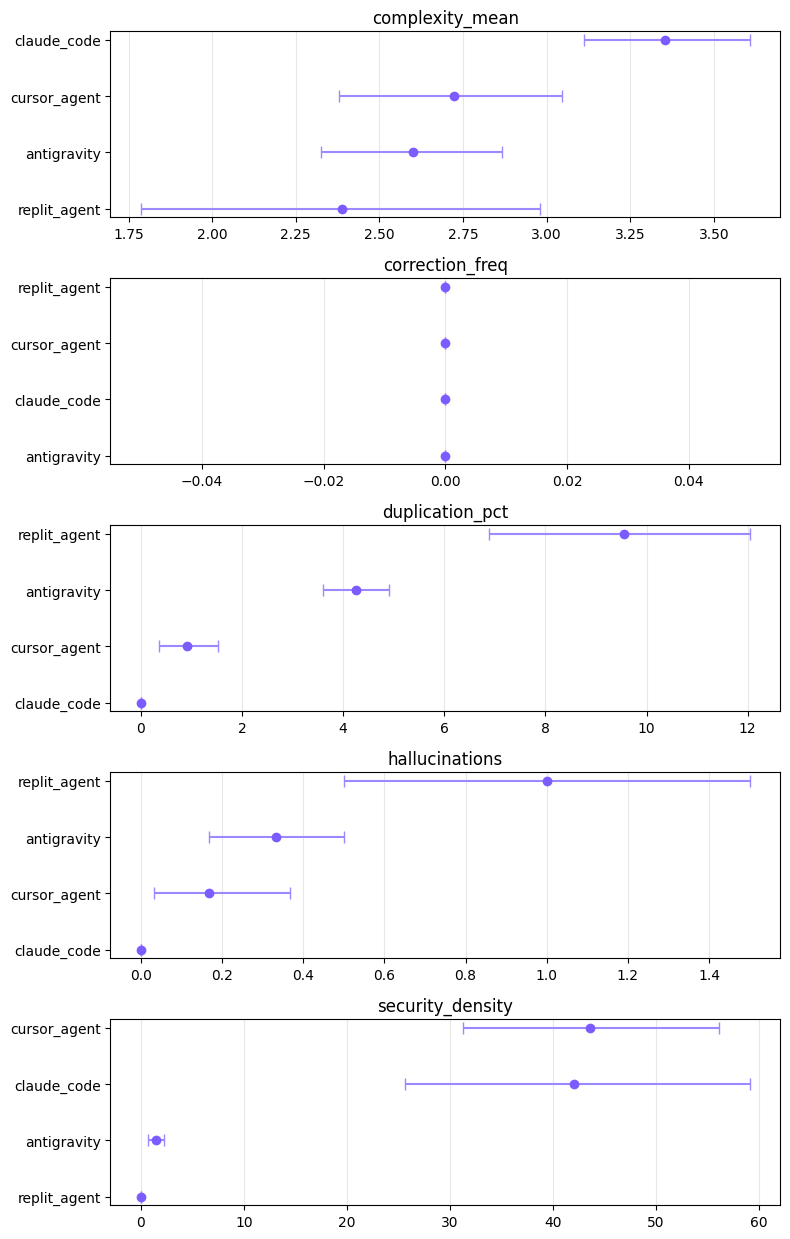

In [7]:
metrics = sorted(df['metric'].unique())
fig, axes = plt.subplots(len(metrics), 1, figsize=(8, 2.5*len(metrics)), squeeze=False)
for ax, metric in zip(axes.flat, metrics):
    rows = summary[summary['metric']==metric].sort_values('mean')
    y = np.arange(len(rows))
    ax.errorbar(rows['mean'], y, xerr=[rows['mean']-rows['ci_lo'], rows['ci_hi']-rows['mean']],
                fmt='o', color='#7c5cff', ecolor='#9b8aff', capsize=4)
    ax.set_yticks(y); ax.set_yticklabels(rows['condition'])
    ax.set_title(metric); ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('forest_plots.png', dpi=150, bbox_inches='tight')
plt.show()

## Violin plots — distribution shape per (condition × metric)

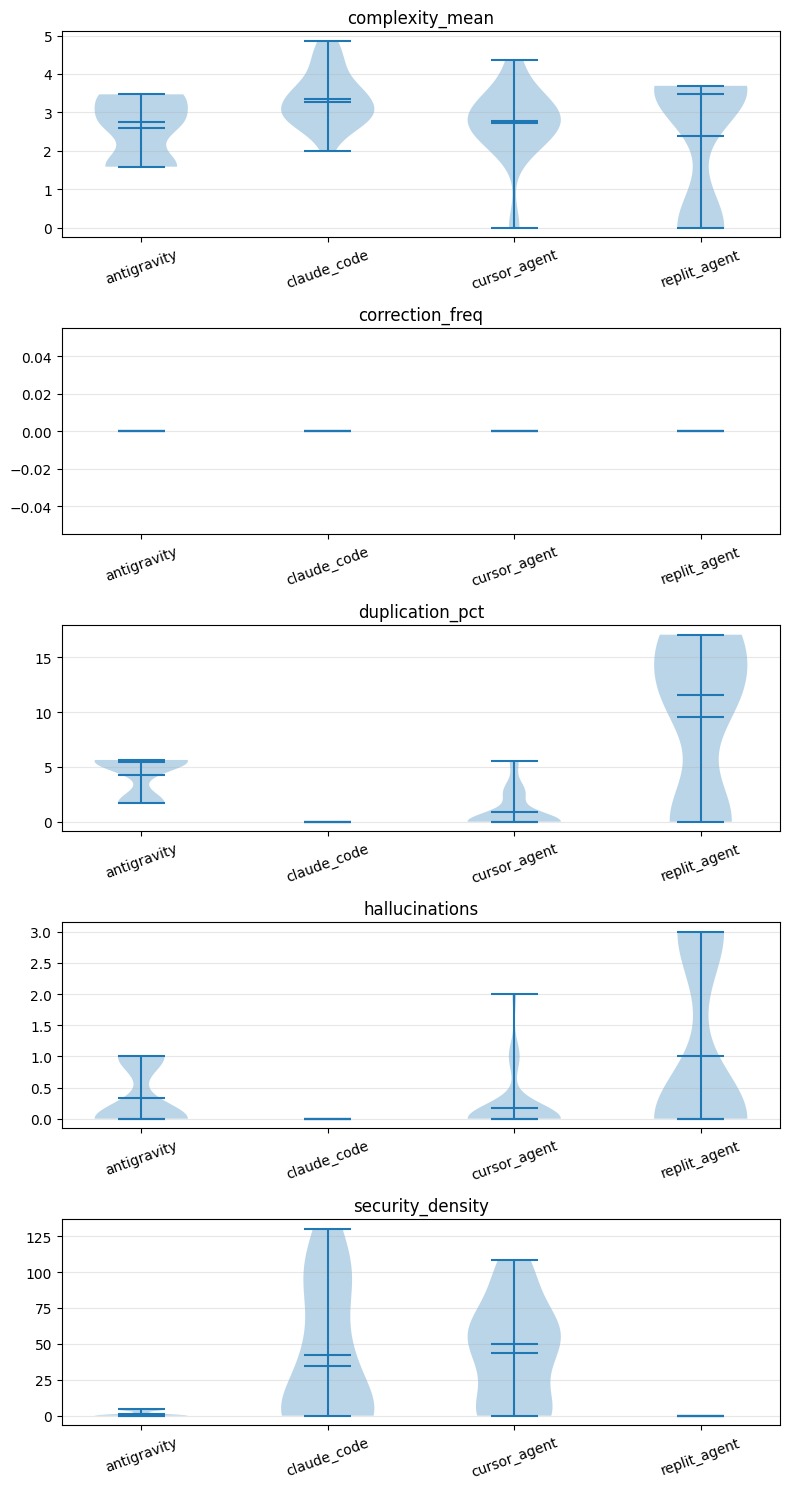

In [8]:
fig, axes = plt.subplots(len(metrics), 1, figsize=(8, 3*len(metrics)), squeeze=False)
for ax, metric in zip(axes.flat, metrics):
    sub = df[df['metric']==metric]
    conditions = sorted(sub['condition'].unique())
    data = [sub[sub['condition']==c]['value'].values for c in conditions]
    parts = ax.violinplot(data, showmeans=True, showmedians=True)
    ax.set_xticks(range(1, len(conditions)+1)); ax.set_xticklabels(conditions, rotation=20)
    ax.set_title(metric); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('violin_plots.png', dpi=150, bbox_inches='tight')
plt.show()

## Refusal / timeout rate (Protocol §8)

Computed from the provenance file, not the CSV (the CSV only contains successful scored runs).

In [9]:
import json
prov_path = CSV.parent / f'{RUN_LABEL}.provenance.json'
if prov_path.exists():
    prov = json.loads(prov_path.read_text())
    if 'statuses' in prov:
        by_cond = pd.DataFrame(prov['statuses']).groupby('condition')['outcome'].value_counts().unstack(fill_value=0)
        by_cond['refusal_rate'] = 1 - by_cond.get('ok', 0) / by_cond.sum(axis=1)
        print('Refusal / failure rate per condition:')
        print(by_cond.round(3))
    else:
        # main_001 provenance records design metadata, not per-run outcomes.
        print(f"Provenance present but has no per-run 'statuses' "
              f"(keys: {sorted(prov)}).")
        print("Refusal/timeout rate not computable from this run's provenance; "
              "the CSV contains only successfully scored runs.")
else:
    print('No provenance file yet.')

Provenance present but has no per-run 'statuses' (keys: ['conditions', 'design', 'deviations', 'kind', 'live_conditions', 'replay_conditions', 'reps_per_cell', 'spec_files', 'timestamp']).
Refusal/timeout rate not computable from this run's provenance; the CSV contains only successfully scored runs.


## Inter-rater reliability for the hallucination heuristic (Protocol §9)

Manual step: hand-label 30 random runs from `data/raw/`, save labels as
`data/labels/hallucination_handlabels.csv` with columns `run_id, n_hallucinated_handlabel`,
then run the cell below to compute Cohen's κ.

In [10]:
from sklearn.metrics import cohen_kappa_score
labels = Path('..')/'data'/'labels'/'hallucination_handlabels.csv'
if labels.exists():
    hand = pd.read_csv(labels)
    auto = df[df['metric']=='hallucinations'].set_index('run_id')['value']
    merged = hand.merge(auto.rename('n_auto'), left_on='run_id', right_index=True, how='inner')
    if len(merged) >= 10:
        k = cohen_kappa_score(merged['n_hallucinated_handlabel'] > 0,
                              merged['n_auto'] > 0)
        print(f"Cohen's κ (any-hallucination presence) = {k:.3f}  on N={len(merged)}")
        print('Interpretation:  <0.4 poor · 0.4-0.6 moderate · 0.6-0.8 good · >0.8 very good')
    else:
        print(f'Have only {len(merged)} matched rows; need >= 10.')
else:
    print(f'No hand-labels yet. Expected at {labels}')

No hand-labels yet. Expected at ../data/labels/hallucination_handlabels.csv
